# BangHallu — Bengali Hallucination Detection
## The complete pipeline, end to end

**What this notebook is.** Everything built after the data was annotated: cleaning Bengali
text, hand-made features, the three input formats, the scoring code, and every model on the
ladder — classical, neural, and pretrained. It runs top to bottom and draws the result at
each step.

**The task.** Given a Bengali question and a candidate answer (sometimes with a supporting
passage), decide whether the answer is **correct** or **made up**.

> **Label convention — the reverse of most papers.**
> `1` = correct / faithful  ·  `0` = hallucinated
> Keep this in mind everywhere below: the *positive* class is the truthful one.

**The one number that matters.** Roughly 60% of this corpus can be answered by checking
whether the answer text simply appears in the passage. A model that learns only that trick
scores well and understands nothing. So every result is reported on the **hard subset** —
the pairs where that trick does *not* separate the right answer from the wrong one.

---

### How this notebook is organised

| Part | What it covers | Code it uses |
|---|---|---|
| 1 | Setup and a data-integrity check | `splits.py`, `audit.py` |
| 2 | What the dataset actually looks like | — |
| 3 | Cleaning and splitting Bengali text (Lab 1) | `text_bn.py` |
| 4 | Hand-made features: edit distance, n-gram LM (Labs 1–3) | `features.py` |
| 5 | What the model actually reads (M9) | `preprocess.py` |
| 6 | Scoring, and the rules a model must beat | `evaluate.py` |
| 7 | The classical models (M1, M2, M11, M12) | `train_classical.py`, `skipgram.py` |
| 8 | Does the textbook cleanup help? (M10) | `train_classical.py` |
| 9 | Neural networks from scratch (M3, M13) | `train_neural.py` |
| 10 | Pretrained encoders (M4, M5) | `train_transformer.py` |
| 11 | Everything side by side, and the findings | — |

---
## Part 1 — Setup

`QUICK = True` reads results that were already measured and recorded in
`results/experiment_log.csv`, so the notebook runs in a few minutes. Set it to `False` to
retrain every model from scratch (hours on a CPU).

Either way the **cheap** steps — cleaning, features, baselines — are computed live below,
not read from a file.

In [1]:
QUICK = True          # False = retrain everything instead of reading recorded results

import sys, os, math, json, csv, warnings, collections
from pathlib import Path

ROOT = Path.cwd()
while not (ROOT / "src" / "splits.py").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent                      # works whether this runs from / or /notebooks
sys.path.insert(0, str(ROOT / "src"))

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 110,
    "axes.titlesize": 12, "axes.titleweight": "600",
    "axes.labelsize": 10, "figure.autolayout": True,
})

# Bengali glyphs need a font that has them. Matplotlib's default does not, so Bengali is kept
# out of the charts and shown as text instead; a missing font would otherwise draw tofu boxes.
CORRECT, WRONG, NEUTRAL, ACCENT = "#2c5530", "#8c2f22", "#8a877f", "#7a2518"

print("repo:", ROOT)
print("mode:", "QUICK (reading recorded results)" if QUICK else "FULL (retraining)")

repo: d:\Bhibranti
mode: QUICK (reading recorded results)


### The data, loaded the one permitted way

`splits.load_split()` is the only sanctioned loader. It drops the 180 pairs that human review
found unusable (PRD §5.1d) — reading the `.jsonl` files directly would train and score on
labels the annotators confirmed were wrong.

**The test split is not loaded anywhere in this notebook.** It is opened exactly once, at the
very end of the project, and nothing here may touch it.

In [2]:
from splits import load_split

train, dev = load_split("train"), load_split("dev")
print(f"train : {len(train):,} records  ({len({r['pair_id'] for r in train}):,} pairs)")
print(f"dev   : {len(dev):,} records  ({len({r['pair_id'] for r in dev}):,} pairs)")
print("test  : deliberately not loaded")

# One record, in full, so the shape of the data is concrete rather than abstract.
example = next(r for r in dev if r["context"] and r["difficulty"] == "hard")
print("\n--- one hard record with a passage ---")
for field in ("question", "candidate_answer", "label", "difficulty", "condition",
              "subject", "hallucination_type"):
    value = str(example[field])
    print(f"  {field:<20}: {value[:95]}")
print(f"  {'context':<20}: {example['context'][:95]}...")

train : 6,134 records  (3,067 pairs)
dev   : 1,238 records  (619 pairs)
test  : deliberately not loaded

--- one hard record with a passage ---
  question            : মেট্রোপলিটান কমিউনিটি চার্চ অফ এডিনবার্গ কত সালে প্রতিষ্ঠিত হয়?
  candidate_answer    : ১৯৯৫
  label               : 1
  difficulty          : hard
  condition           : has_context
  subject             : history
  hallucination_type  : none
  context             : মেট্রোপলিটন কমিউনিটি চার্চ অফ এডিনবার্গ, যা ট্রিনিটি মেট্রোপলিটন কমিউনিটি চার্চ নামেও পরিচিত, ছ...


### The shortcut gate

Before trusting any score, the project checks that the labels cannot be guessed from surface
features of the answer alone — length, punctuation, digit counts. If a model could reach 0.60
that way, the corpus itself would be broken and every result below would be meaningless.

This is run as a gate: it **exits non-zero** if it fails.

In [3]:
import subprocess
gate = subprocess.run([sys.executable, "src/audit.py", "--data", "data/splits",
                       "--probe", "metadata"], cwd=ROOT, capture_output=True, text=True)
print(gate.stdout[-700:])
assert gate.returncode == 0, "THE GATE FAILED - nothing below can be trusted"

ns train/test)
  metadata-only macro-F1      = 0.534   [CLEAN]
    leading coefficients: latin_ratio=+0.644, caps_ratio=-0.452, period=+0.096, digit_ratio=-0.057

PROBES - usable records only (8,600; 360 in excluded pairs removed, PRD Q5)
  metadata-only macro-F1      = 0.514   [CLEAN]
    leading coefficients: latin_ratio=+0.586, period=+0.073, caps_ratio=+0.056, mean_token_len=+0.028

STRUCTURAL CHECKS
  all structural checks passed

metadata probe: all records 0.534, usable records 0.514  (gate uses the worse)
GATE V1 PASSED: metadata probe 0.534 < 0.6



---
## Part 2 — What the dataset looks like

Four things decide how every later result has to be read: the class balance, how many records
have a passage to check against, how many are *hard*, and how the subjects are spread.

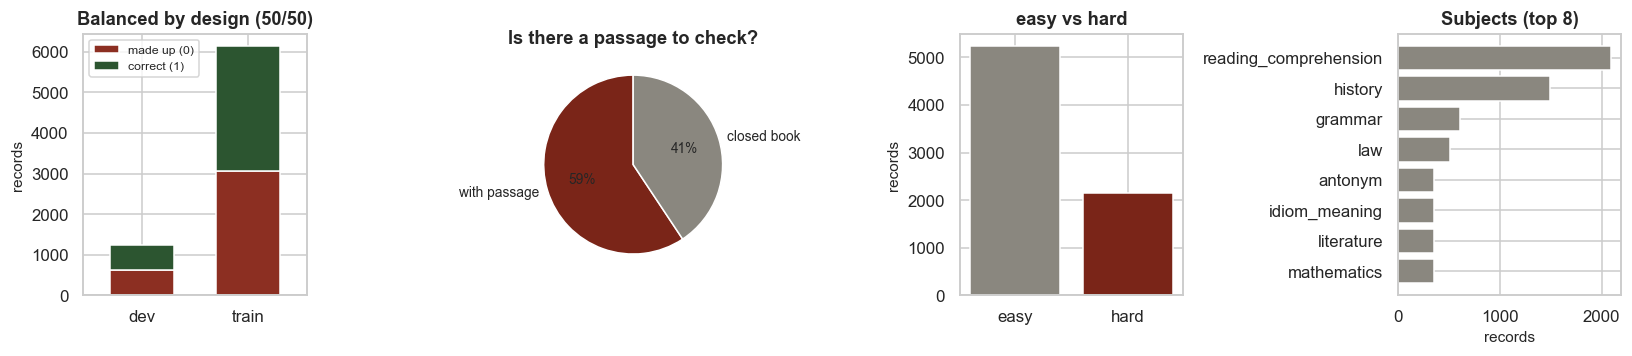

hard =  the string-matching shortcut does NOT separate this pair's two answers.
       Those are the records the whole project is judged on.


In [4]:
frame = pd.DataFrame([{
    "split": name, "label": r["label"], "condition": r["condition"],
    "difficulty": r["difficulty"], "subject": r["subject"],
    "answer_chars": len(r["candidate_answer"]),
    "context_chars": len(r["context"] or ""),
} for name, rows in (("train", train), ("dev", dev)) for r in rows])

fig, axes = plt.subplots(1, 4, figsize=(15, 3.4))

counts = frame.groupby(["split", "label"]).size().unstack()
counts.columns = ["made up (0)", "correct (1)"]
counts.plot(kind="bar", stacked=True, ax=axes[0], color=[WRONG, CORRECT], width=.6)
axes[0].set_title("Balanced by design (50/50)"); axes[0].set_xlabel(""); axes[0].set_ylabel("records")
axes[0].tick_params(axis="x", rotation=0); axes[0].legend(fontsize=8)

cond = frame["condition"].value_counts()
axes[1].pie(cond, labels=["with passage" if c == "has_context" else "closed book" for c in cond.index],
            autopct="%1.0f%%", colors=[ACCENT, NEUTRAL], startangle=90,
            textprops={"fontsize": 9})
axes[1].set_title("Is there a passage to check?")

diff = frame["difficulty"].value_counts()
axes[2].bar(diff.index, diff.values, color=[NEUTRAL if d == "easy" else ACCENT for d in diff.index])
axes[2].set_title("easy vs hard"); axes[2].set_ylabel("records")

top = frame["subject"].value_counts().head(8)
axes[3].barh(top.index[::-1], top.values[::-1], color=NEUTRAL)
axes[3].set_title("Subjects (top 8)"); axes[3].set_xlabel("records")
plt.show()

print("hard =  the string-matching shortcut does NOT separate this pair's two answers.")
print("       Those are the records the whole project is judged on.")

**Why that third chart is the important one.** `hard` is not a human judgement of difficulty.
It is measured: a pair is *hard* when checking "does the answer appear in the passage?" fails
to tell its correct answer from its wrong one. Those are the records where a model has to do
something real.

---
## Part 3 — Cleaning and splitting Bengali text (Lab 1)

Lab 1's English recipe cannot be used as-is. `re.sub(r'[^A-Za-z\s]', '', text)` deletes every
Bengali character and every digit; NLTK's tokenizer, stop-word list and Porter stemmer are all
English-only. `src/text_bn.py` is the Bengali replacement.

In [5]:
from text_bn import clean, tokenize, preprocess as prep_variant

sample = "কলেজের ছাত্ররা ১৯৭১ সালে বইটি পড়েনি।[১২]"
print("raw              :", sample)
print("after clean()    :", clean(sample))
print("after tokenize() :", tokenize(clean(sample)))

print("\nThe cleaning steps, in order:")
for step in ["Unicode NFC (one code point per character)",
             "strip citation marks like [12] - but never LaTeX such as sqrt[7]{n}",
             "Bengali digits -> ASCII digits, so 1971 and ১৯৭১ are the same number",
             "collapse whitespace"]:
    print("   *", step)

raw              : কলেজের ছাত্ররা ১৯৭১ সালে বইটি পড়েনি।[১২]
after clean()    : কলেজের ছাত্ররা 1971 সালে বইটি পড়েনি।
after tokenize() : ['কলেজের', 'ছাত্ররা', '1971', 'সালে', 'বইটি', 'পড়েনি', '।']

The cleaning steps, in order:
   * Unicode NFC (one code point per character)
   * strip citation marks like [12] - but never LaTeX such as sqrt[7]{n}
   * Bengali digits -> ASCII digits, so 1971 and ১৯৭১ are the same number
   * collapse whitespace


### The five preprocessing variants

`V1` is the default everywhere. The others exist so the question *"does the textbook cleanup
actually help?"* can be answered with a measurement instead of an opinion (Part 8).

`V2-demo` is deliberately broken: it uses the published stop-word list **without** protecting
negation and number words. It is here to show the damage that causes.

In [6]:
demo = "কলেজের ছাত্ররা এবং বইটি বিভক্ত নয়"
rows = []
for variant in ["V0", "V1", "V2", "V3", "V4", "V2-demo"]:
    produced = prep_variant(demo, variant)
    rows.append({"variant": variant, "tokens": len(produced), "result": " ".join(produced)})
display(pd.DataFrame(rows).set_index("variant"))

print("Watch the last row: 'নয়' (= 'not') is gone.")
print("V2 keeps it because negation words are protected; V2-demo does not.")
print("Part 8 measures exactly what that costs.")

,tokens,result
variant,,
V0,6,কলেজের ছাত্ররা এবং বইটি বিভক্ত নয়
V1,6,কলেজের ছাত্ররা এবং বইটি বিভক্ত নয়
V2,5,কলেজের ছাত্ররা বইটি বিভক্ত নয়
V3,6,কলেজ ছাত্র এবং বইটি বিভক্ত নয়
V4,5,কলেজ ছাত্র বইটি বিভক্ত নয়
V2-demo,4,কলেজের ছাত্ররা বইটি বিভক্ত


Watch the last row: 'নয়' (= 'not') is gone.
V2 keeps it because negation words are protected; V2-demo does not.
Part 8 measures exactly what that costs.


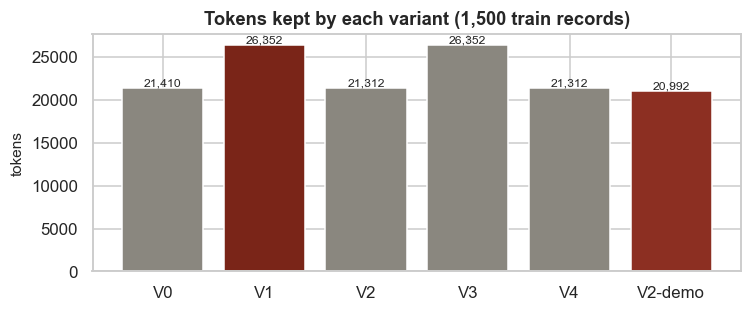

V1 (the default) is highlighted. V2-demo throws away the most, including words that matter.


In [7]:
# How much each variant changes the real corpus, measured on 1,500 train records.
sample_rows = train[:1500]
sizes = {}
for variant in ["V0", "V1", "V2", "V3", "V4", "V2-demo"]:
    sizes[variant] = sum(len(prep_variant(r["candidate_answer"] + " " + r["question"], variant))
                         for r in sample_rows)

fig, ax = plt.subplots(figsize=(7, 3))
bars = ax.bar(list(sizes), list(sizes.values()),
              color=[ACCENT if v == "V1" else (WRONG if v == "V2-demo" else NEUTRAL) for v in sizes])
ax.set_title("Tokens kept by each variant (1,500 train records)")
ax.set_ylabel("tokens")
for bar, value in zip(bars, sizes.values()):
    ax.text(bar.get_x() + bar.get_width() / 2, value, f"{value:,}", ha="center", va="bottom", fontsize=8)
plt.show()
print("V1 (the default) is highlighted. V2-demo throws away the most, including words that matter.")

---
## Part 4 — Hand-made features (Labs 1–3)

A bag of words can see *which* words an answer uses, but not whether those words **match the
passage in front of it**. These features add exactly that.

Every one of them compares a record only with **its own** question and passage — never with
another record. That is what keeps this from being retrieval, which the project forbids.

| Feature | Lab | Meaning |
|---|---|---|
| `exact_in_passage` | 2 | the answer appears word for word |
| `edit_passage` | 1 | share of the answer's letters that must change to find it |
| `token_overlap` | 2 | share of the answer's words that are in the passage |
| `lm_passage` | 2 | how readily the passage's own character n-gram model produces this answer |
| `edit_question` | 1 | how much the answer just repeats the question |

In [8]:
from features import extract_features, edit_distance, best_match_distance, FEATURE_NAMES

print("Lab 1's edit distance, on the lab's own example:")
print(f"  edit_distance('kitten', 'sitting') = {edit_distance('kitten', 'sitting')}  (expected 3)")

print("\nFinding an answer inside a long passage (the 'free start' version):")
passage = "নির্মাণকাজ ১৭০৪ সালে শুরু হয়েছিল"
for answer in ["১৭০৪", "১৭০৫"]:
    d = best_match_distance(answer, passage)
    print(f"  best_match_distance({answer!r}, passage) = {d}"
          f"   <- {'found exactly' if d == 0 else f'{d} character off'}")

Lab 1's edit distance, on the lab's own example:
  edit_distance('kitten', 'sitting') = 3  (expected 3)

Finding an answer inside a long passage (the 'free start' version):
  best_match_distance('১৭০৪', passage) = 0   <- found exactly
  best_match_distance('১৭০৫', passage) = 1   <- 1 character off


In [9]:
# The same question, with its correct and its made-up answer, side by side.
pairs = collections.defaultdict(list)
for r in dev:
    pairs[r["pair_id"]].append(r)
pair = next(p for p in pairs.values()
            if len(p) == 2 and p[0]["context"] and p[0]["difficulty"] == "hard")
good = next(r for r in pair if r["label"] == 1)
bad = next(r for r in pair if r["label"] == 0)

print("question :", good["question"][:100])
print("CORRECT  :", good["candidate_answer"][:80])
print("MADE UP  :", bad["candidate_answer"][:80])

comparison = pd.DataFrame({
    "correct answer": extract_features(good),
    "made-up answer": extract_features(bad),
}).loc[["exact_in_passage", "edit_passage", "token_overlap", "lm_passage", "edit_question"]]
comparison["gap"] = comparison["correct answer"] - comparison["made-up answer"]
display(comparison.round(3))

question : মেট্রোপলিটান কমিউনিটি চার্চ অফ এডিনবার্গ কত সালে প্রতিষ্ঠিত হয়?
CORRECT  : ১৯৯৫
MADE UP  : ১৯৬৮


,correct answer,made-up answer,gap
exact_in_passage,1.000,1.000,0.0
edit_passage,0.000,0.000,0.0
token_overlap,1.000,1.000,0.0
lm_passage,0.032,0.032,0.0
edit_question,1.000,1.000,0.0


### Which features actually carry signal?

AUC answers "if I pick one correct and one wrong answer at random, how often does this feature
rank them the right way round?" 0.50 is useless; 1.00 is perfect.

The interesting part is the **second** panel — the same features on the hard subset only.

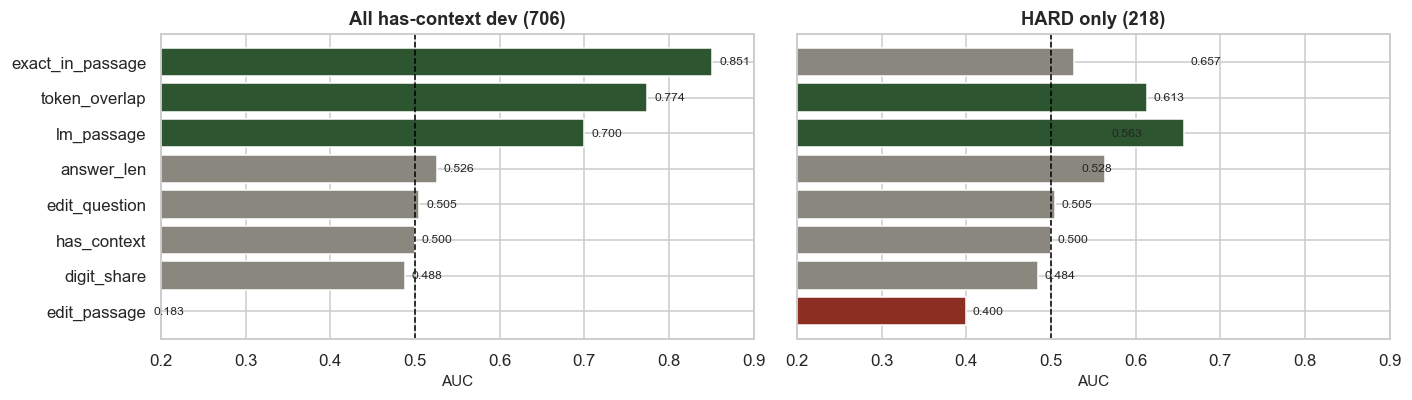

exact_in_passage : 0.851 overall -> 0.528 on hard
lm_passage       : 0.700 overall -> 0.657 on hard

This is the whole problem in one chart. The feature that dominates overall
(does the answer appear in the passage) collapses to near-useless on the hard
records, and the language-model feature becomes the most informative one.


In [10]:
from sklearn.metrics import roc_auc_score

grounded = [r for r in dev if r["context"]]
hard = [r for r in grounded if r["difficulty"] == "hard"]

def feature_aucs(rows):
    table = [extract_features(r) for r in rows]
    labels = [r["label"] for r in rows]
    out = {}
    for name in FEATURE_NAMES:
        values = [f[name] for f in table]
        out[name] = roc_auc_score(labels, values) if len(set(values)) > 1 else 0.5
    return out

auc_all, auc_hard = feature_aucs(grounded), feature_aucs(hard)

fig, axes = plt.subplots(1, 2, figsize=(13, 3.8), sharey=True)
for ax, (title, data) in zip(axes, [(f"All has-context dev ({len(grounded)})", auc_all),
                                    (f"HARD only ({len(hard)})", auc_hard)]):
    order = sorted(data, key=data.get)
    values = [data[k] for k in order]
    colours = [CORRECT if v > 0.6 else (NEUTRAL if v > 0.45 else WRONG) for v in values]
    ax.barh(order, values, color=colours)
    ax.axvline(0.5, color="black", lw=1, ls="--")
    ax.set_xlim(0.2, 0.9); ax.set_title(title); ax.set_xlabel("AUC")
    for i, v in enumerate(values):
        ax.text(v + .008, i, f"{v:.3f}", va="center", fontsize=8)
plt.show()

print(f"exact_in_passage : {auc_all['exact_in_passage']:.3f} overall -> {auc_hard['exact_in_passage']:.3f} on hard")
print(f"lm_passage       : {auc_all['lm_passage']:.3f} overall -> {auc_hard['lm_passage']:.3f} on hard")
print()
print("This is the whole problem in one chart. The feature that dominates overall")
print("(does the answer appear in the passage) collapses to near-useless on the hard")
print("records, and the language-model feature becomes the most informative one.")

---
## Part 5 — What the model actually reads (M9)

Three input formats. The rule that matters: when an input is too long, the **passage** is cut —
never the question and never the answer. A model that cannot see the answer cannot judge it.

F1  (question + answer (no passage))
     মেট্রোপলিটান কমিউনিটি চার্চ অফ এডিনবার্গ কত সালে প্রতিষ্ঠিত হয়? 1995...
F2  (passage + question + answer, all in one)
     মেট্রোপলিটন কমিউনিটি চার্চ অফ এডিনবার্গ, যা ট্রিনিটি মেট্রোপলিটন কমিউনিটি চার্চ নামেও পরিচিত, ছিল মেট্রোপলিটন ...
F3  (passage as one segment, question + answer as the other)
     মেট্রোপলিটন কমিউনিটি চার্চ অফ এডিনবার্গ, যা ট্রিনিটি মেট্রোপলিটন কমিউনিটি চার্চ নামেও পরিচিত, ছিল মেট্রোপলিটন ...


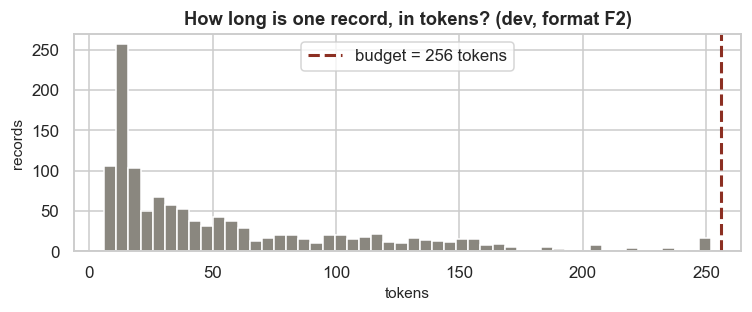

median 34 tokens | 90th percentile 138 | longest 252
only 0.0% exceed the budget, and for those the PASSAGE is what gets cut


In [11]:
from preprocess import as_text, as_tokens, record_parts, MAX_TOKENS, FORMATS

for fmt, description in FORMATS.items():
    text = as_text(example, fmt)
    print(f"{fmt}  ({description})")
    print(f"     {text[:110]}...")

lengths = pd.Series([len(as_tokens(r, "F2")) for r in dev])
fig, ax = plt.subplots(figsize=(7, 3))
ax.hist(lengths, bins=50, color=NEUTRAL)
ax.axvline(MAX_TOKENS, color=WRONG, lw=2, ls="--", label=f"budget = {MAX_TOKENS} tokens")
ax.set_title("How long is one record, in tokens? (dev, format F2)")
ax.set_xlabel("tokens"); ax.set_ylabel("records"); ax.legend()
plt.show()

print(f"median {lengths.median():.0f} tokens | 90th percentile {lengths.quantile(.9):.0f} | longest {lengths.max()}")
print(f"only {(lengths > MAX_TOKENS).mean():.1%} exceed the budget, and for those the PASSAGE is what gets cut")

---
## Part 6 — Scoring, and the bar every model must clear

**macro-F1**, not accuracy. Accuracy rewards a model that always answers "correct": it would
score 0.50 on a balanced set while being worthless. macro-F1 averages the two classes, so that
model scores about 0.33.

And before any model is called good, it has to beat two rules that involve **no learning at
all**.

In [12]:
import evaluate

truth = [r["label"] for r in dev]
pretend = {
    "a perfect model": list(truth),
    "always says 'correct'": [1] * len(dev),
    "random guessing": list(np.random.default_rng(42).integers(0, 2, len(dev))),
}
print(f"{'made-up model':<26}{'macro-F1':>10}{'accuracy':>10}")
for name, predicted in pretend.items():
    r = evaluate.evaluate(dev, predicted)
    print(f"{name:<26}{r.macro_f1:>10.3f}{r.accuracy:>10.3f}")
print("\n'always correct' gets 0.500 accuracy but only 0.333 macro-F1 — which is the point.")

made-up model               macro-F1  accuracy
a perfect model                1.000     1.000
always says 'correct'          0.333     0.500
random guessing                0.510     0.510

'always correct' gets 0.500 accuracy but only 0.333 macro-F1 — which is the point.


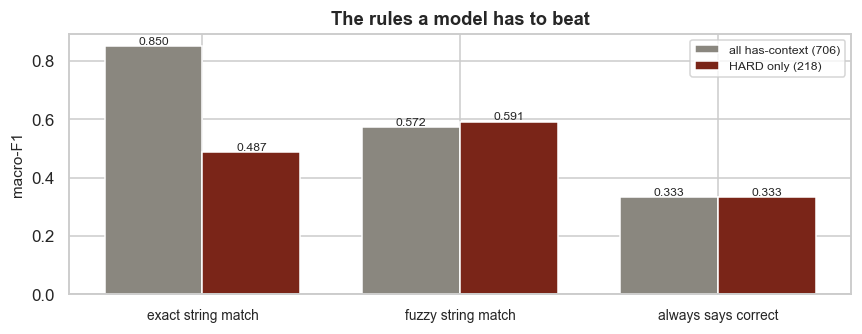

A string matcher scores 0.850 on all has-context records.
On the HARD records the same rule gets 0.487, and the fuzzy version 0.591.

So the real bar is 0.591 on hard — not 0.850.


In [13]:
# The two no-learning rules, recomputed on exactly these records.
bars_all = evaluate.baselines_for(grounded)
bars_hard = evaluate.baselines_for(hard)

fig, ax = plt.subplots(figsize=(8, 3.2))
names = list(bars_all)
x = np.arange(len(names)); width = .38
ax.bar(x - width/2, [bars_all[k] for k in names], width, label=f"all has-context ({len(grounded)})", color=NEUTRAL)
ax.bar(x + width/2, [bars_hard[k] for k in names], width, label=f"HARD only ({len(hard)})", color=ACCENT)
ax.set_xticks(x); ax.set_xticklabels(names, fontsize=9)
ax.set_ylabel("macro-F1"); ax.set_title("The rules a model has to beat"); ax.legend(fontsize=8)
for i, k in enumerate(names):
    ax.text(i - width/2, bars_all[k], f"{bars_all[k]:.3f}", ha="center", va="bottom", fontsize=8)
    ax.text(i + width/2, bars_hard[k], f"{bars_hard[k]:.3f}", ha="center", va="bottom", fontsize=8)
plt.show()

FUZZY_BAR = bars_hard["fuzzy string match"]
EXACT_BAR = bars_hard["exact string match"]
print(f"A string matcher scores {bars_all['exact string match']:.3f} on all has-context records.")
print(f"On the HARD records the same rule gets {EXACT_BAR:.3f}, and the fuzzy version {FUZZY_BAR:.3f}.")
print(f"\nSo the real bar is {FUZZY_BAR:.3f} on hard — not {bars_all['exact string match']:.3f}.")

---
## Part 7 — The classical models (M1, M2, M11, M12)

Twelve models: bag-of-words and TF-IDF into Naive Bayes / Logistic Regression / SVM (M1),
a character language model (M11), our own Skip-gram word vectors into Logistic Regression and
XGBoost (M2), and the similarity features above into Logistic Regression (M12).

In [14]:
LOG = pd.read_csv(ROOT / "results" / "experiment_log.csv")

def hard_from_notes(note):
    for piece in str(note).split(";"):
        if "has-context+hard" in piece:
            return float(piece.split()[-1])
    return np.nan

LOG["hard"] = LOG["notes"].apply(hard_from_notes)
LOG["family"] = LOG["model"].str.split("_").str[0]
LOG["short"] = LOG["model"].str.split("_", n=1).str[1]

def leaderboard(families, ablation=False):
    rows = LOG[LOG["family"].isin(families) & LOG["dev_macro_f1"].notna()].copy()
    if not ablation:
        rows = rows[~rows["notes"].str.contains("M10 ablation", na=False)]
    rows = rows[rows["preprocessing"].isin(["text_bn_V1", "pretrained"])]
    grouped = rows.groupby("short").agg(
        overall=("dev_macro_f1", "mean"), spread=("dev_macro_f1", "std"),
        hard=("hard", "mean"), runs=("dev_macro_f1", "size")).reset_index()
    return grouped.sort_values("hard", ascending=False)

classical = leaderboard(["M1", "M2", "M11", "M12"])
display(classical.round(3).set_index("short"))

,overall,spread,hard,runs
short,,,,
tfidf_logreg,0.552,0.003,0.618,5
tfidf_svm,0.550,0.001,0.610,4
char_lm,0.529,0.000,0.605,3
bow_nb,0.531,0.001,0.600,4
tfidf_nb,0.527,0.000,0.592,4
bow_logreg,0.558,0.001,0.592,4
bow_svm,0.542,0.004,0.560,5
skipgram_mean_xgb,0.505,0.014,0.533,7
skipgram_tfidf_xgb,0.522,0.007,0.521,7


### The chart that matters most in this project

Each dot is a model. Horizontal = how it scores **overall**. Vertical = how it scores on the
**hard** records. A model on the dashed diagonal does equally well on both.

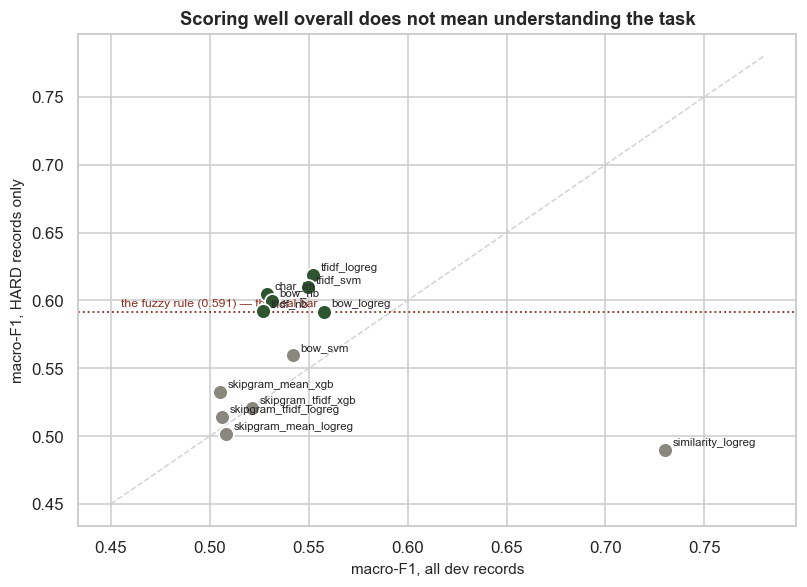

Look at 'similarity_logreg': best overall at 0.730,
but only 0.490 on hard — BELOW the 0.591 rule.
Its heaviest weight is 'does the answer appear in the passage'. It learned the shortcut.

Judged by the overall column it would look like the best model in the project.


In [15]:
fig, ax = plt.subplots(figsize=(7.5, 5.5))
ax.plot([.45, .78], [.45, .78], ls="--", color="lightgrey", lw=1, zorder=0)
ax.axhline(FUZZY_BAR, color=WRONG, lw=1.2, ls=":", zorder=1)
ax.text(.455, FUZZY_BAR + .004, f"the fuzzy rule ({FUZZY_BAR:.3f}) — the real bar",
        fontsize=8, color=WRONG)

for _, row in classical.iterrows():
    beats = row["hard"] > FUZZY_BAR
    ax.scatter(row["overall"], row["hard"], s=95, zorder=3,
               color=CORRECT if beats else NEUTRAL,
               edgecolor="white", linewidth=1.2)
    ax.annotate(row["short"], (row["overall"], row["hard"]), fontsize=7.5,
                xytext=(5, 3), textcoords="offset points")

ax.set_xlabel("macro-F1, all dev records"); ax.set_ylabel("macro-F1, HARD records only")
ax.set_title("Scoring well overall does not mean understanding the task")
plt.show()

worst = classical.loc[classical["hard"].idxmin()]
best_overall = classical.loc[classical["overall"].idxmax()]
print(f"Look at '{best_overall['short']}': best overall at {best_overall['overall']:.3f},")
print(f"but only {best_overall['hard']:.3f} on hard — BELOW the {FUZZY_BAR:.3f} rule.")
print("Its heaviest weight is 'does the answer appear in the passage'. It learned the shortcut.")
print("\nJudged by the overall column it would look like the best model in the project.")

---
## Part 8 — Does the textbook cleanup actually help? (M10)

Every NLP course teaches the same three steps: clean the text, drop common words, cut words to
their root. Nobody checks whether they help. This does: the same model, retrained once per
variant, with everything else held fixed.

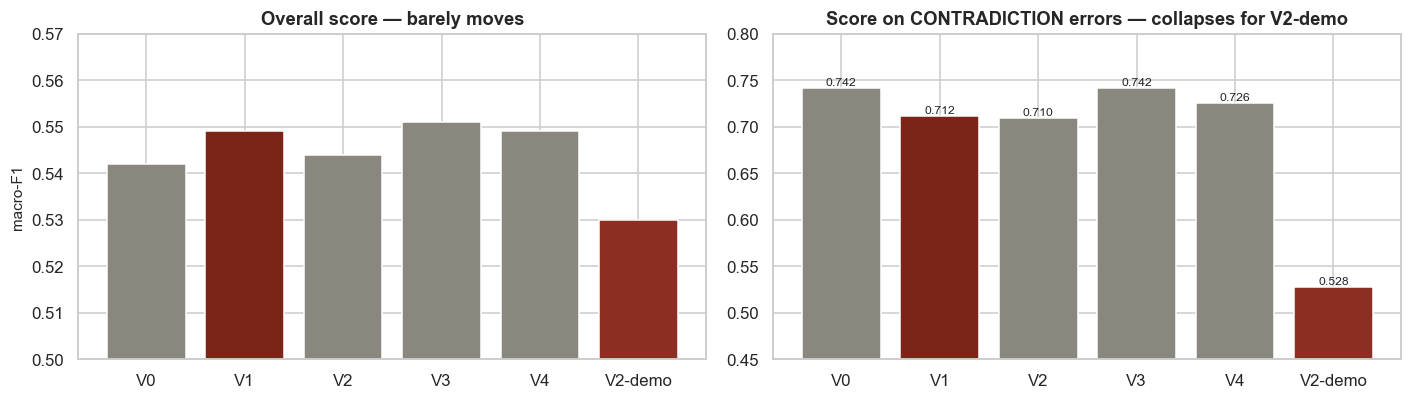

V1 keeps negation words       : contradiction score 0.712
V2-demo throws them away      : contradiction score 0.528
                        cost  : 0.184  (26% of the score)


In [16]:
ablation_path = ROOT / "results" / "tables" / "table6_preprocessing_ablation.csv"
if ablation_path.exists():
    ab = pd.read_csv(ablation_path)
    m1 = ab[ab["model"] == "tfidf_logreg"]

    fig, axes = plt.subplots(1, 2, figsize=(13, 3.8))
    order = ["V0", "V1", "V2", "V3", "V4", "V2-demo"]
    m1 = m1.set_index("variant").loc[order].reset_index()
    colours = [ACCENT if v == "V1" else (WRONG if v == "V2-demo" else NEUTRAL) for v in m1["variant"]]

    axes[0].bar(m1["variant"], m1["overall"], color=colours)
    axes[0].set_ylim(.50, .57); axes[0].set_title("Overall score — barely moves")
    axes[0].set_ylabel("macro-F1")

    axes[1].bar(m1["variant"], m1["contradiction"], color=colours)
    axes[1].set_ylim(.45, .80)
    axes[1].set_title("Score on CONTRADICTION errors — collapses for V2-demo")
    for i, v in enumerate(m1["contradiction"]):
        axes[1].text(i, v, f"{v:.3f}", ha="center", va="bottom", fontsize=8)
    plt.show()

    v1 = float(m1.loc[m1["variant"] == "V1", "contradiction"].iloc[0])
    demo = float(m1.loc[m1["variant"] == "V2-demo", "contradiction"].iloc[0])
    print(f"V1 keeps negation words       : contradiction score {v1:.3f}")
    print(f"V2-demo throws them away      : contradiction score {demo:.3f}")
    print(f"                        cost  : {v1 - demo:.3f}  ({(v1 - demo) / v1:.0%} of the score)")
else:
    print("run: python src/train_classical.py --ablation --table")

### Why this is the most important slide in Part 8

Look at the two charts together. V2-demo's **overall** score barely moved — it is within a
couple of points of everything else. Its **contradiction** score fell off a cliff.

A contradiction error is often a single word:

> passage: …ছাত্ররা আন্দোলন **করেছিল** (the students *did* protest)
> answer:  …ছাত্ররা আন্দোলন **করেনি** (the students did *not* protest)

Delete "নি" and the two sentences contain the same words. The model has nothing left to tell
them apart — and the headline number never shows it. That is why results in this project are
always broken down by error type, and why `configs/bn_protected_words.txt` exists.

---
## Part 9 — Neural networks, built from scratch (M3, M13)

The first models that can read a sentence *in order*. Five of them: a plain RNN, a
bidirectional RNN, a stacked BiLSTM, a BiLSTM with attention (Lab 4), and a Transformer
encoder built from PyTorch's own layers with **no pretraining at all** (Lab 5).

Words start from the Skip-gram vectors trained in Part 7 — our own, from this corpus only.

In [17]:
neural = leaderboard(["M3", "M13"])
if len(neural):
    display(neural.round(3).set_index("short"))
else:
    print("no neural runs recorded yet — run: python src/train_neural.py --all --seeds --log")

,overall,spread,hard,runs
short,,,,
rnn,0.560,0.011,0.605,3
bilstm_attn,0.551,0.004,0.598,3
bilstm,0.551,0.005,0.585,3
birnn,0.553,0.002,0.583,3
transformer_scratch,0.465,0.089,0.433,3


### Three mistakes in the lab code, and what this project does instead

These are worth showing in detail, because each one would quietly produce a *worse model*
rather than an error message. `--check` demonstrates all three on real records.

In [18]:
check = subprocess.run([sys.executable, "src/train_neural.py", "--check"],
                       cwd=ROOT, capture_output=True, text=True)
print(check.stdout)
assert check.returncode == 0, "a rule failed"

NEURAL CHECK - real dev records, shortest to longest input
  Skip-gram gave a starting vector to 100.0% of the 17,703-word vocabulary

  FIX 1 - the final state comes from the real last word, not from padding.
  'alone' runs each record by itself with no padding at all: the ground truth.
   tokens   packed vs alone   unpacked vs alone
        6          0.000000            0.517552
       11          0.000000            0.391612
       15          0.000000            0.547968
       26          0.000000            0.567565
       42          0.000000            0.519753
       69          0.000000            0.398328
      119          0.000000            0.367520
      252          0.000000            0.000000

  stacked BiLSTM, packed vs alone, worst difference over 8 records: 0.000000

  ATTENTION - padding gets no weight, and every row of weights sums to 1.
  total weight on padding: 0.00e+00     worst |row sum - 1|: 1.19e-07

  FIX 2 - padding cannot change the Transformer's answe

Reading that output:

1. **Padding corrupts the RNN's memory.** Lab 4 reads the network's state at the *last*
   position of a padded batch — so for a short record, its "summary of the sentence" is really
   the state after running over `<PAD>`. The table shows the lab's way is off by ~0.5 per
   number, and is correct only for the one longest record in the batch (which has no padding).
2. **Lab 5 averages the Transformer's output over the padding too.** Harmless for its 8-word
   toy sentences; wrong for our 3–250 token inputs.
3. **Lab 5 scales word vectors by √d but leaves their default starting size**, making them
   ~11× larger than the position signal — so the model effectively cannot hear word order.

Fixing the third one is not in the project guide; it was found while building this step.

training on: CPU (10 threads)


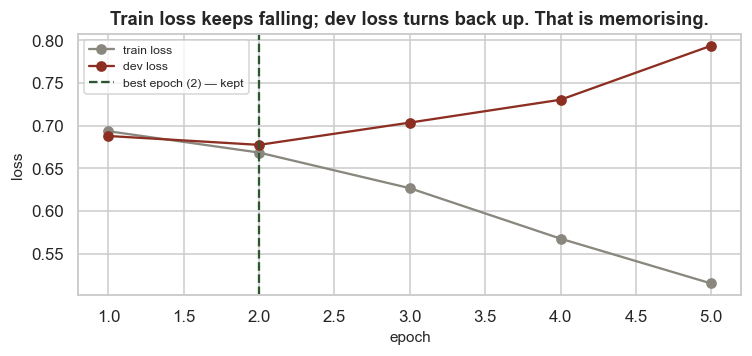

Trained 5 epochs, kept epoch 2.
With 6,134 records and ~3.5 million weights, the model memorises within a few passes.
Early stopping exists to catch exactly this, and returns to the best epoch — not the last.


In [19]:
# What overfitting looks like, on a real run. One model, a few epochs, live.
import torch, train_neural as tn

device = tn.pick_device()
print("training on:", tn.describe_device(device))
vocab = tn.build_vocabulary(train)
vectors = tn.load_or_train_vectors(42, "V1")
fitted = tn.fit_neural("rnn", train, dev, seed=42, vectors=vectors, vocab=vocab,
                       max_epochs=6 if QUICK else tn.RNN_MAX_EPOCHS, device=device, verbose=False)

history = pd.DataFrame(fitted.history)
fig, ax = plt.subplots(figsize=(7, 3.4))
ax.plot(history["epoch"], history["train_loss"], marker="o", label="train loss", color=NEUTRAL)
ax.plot(history["epoch"], history["dev_loss"], marker="o", label="dev loss", color=WRONG)
ax.axvline(fitted.best_epoch, color=CORRECT, ls="--", lw=1.5,
           label=f"best epoch ({fitted.best_epoch}) — kept")
ax.set_xlabel("epoch"); ax.set_ylabel("loss"); ax.legend(fontsize=8)
ax.set_title("Train loss keeps falling; dev loss turns back up. That is memorising.")
plt.show()

print(f"Trained {fitted.epochs_run} epochs, kept epoch {fitted.best_epoch}.")
print("With 6,134 records and ~3.5 million weights, the model memorises within a few passes.")
print("Early stopping exists to catch exactly this, and returns to the best epoch — not the last.")

### Where the attention model looked

The BiLSTM with attention is the only model on the ladder that can show *where* it looked.

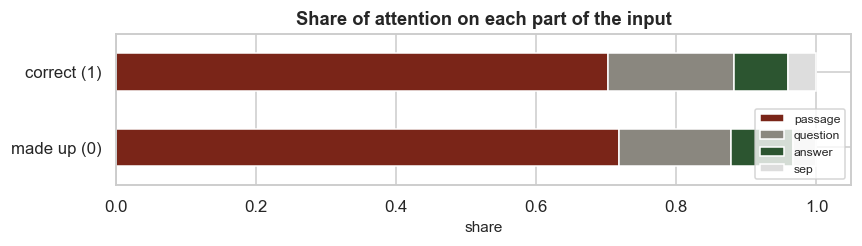

Most attention lands on the passage, which is at least the right place to look.
Careful: attention shows what the model USED, not that it reasoned.


In [20]:
attention_files = sorted((ROOT / "results" / "tables").glob("attention_*.csv"))
if attention_files:
    att = pd.read_csv(attention_files[-1])
    means = att.groupby("label")[["passage", "question", "answer", "sep"]].mean()
    means.index = ["made up (0)", "correct (1)"]
    ax = means.plot(kind="barh", stacked=True, figsize=(8, 2.4),
                    color=[ACCENT, NEUTRAL, CORRECT, "#dddddd"])
    ax.set_title("Share of attention on each part of the input")
    ax.set_xlabel("share"); ax.legend(fontsize=8, loc="lower right")
    plt.show()
    print(f"Most attention lands on the passage, which is at least the right place to look.")
    print("Careful: attention shows what the model USED, not that it reasoned.")
else:
    print("run: python src/train_neural.py --model bilstm_attn --attention")

---
## Part 10 — Pretrained encoders (M4, M5)

The first rung that has seen text from **outside this corpus**. Everything before it learned
only from the 6,134 training records.

The measurement this step exists to make:

> `transformer_scratch` and BanglaBERT are the **same architecture family**.
> One has pretraining; one does not. **The gap between them is what pretraining is worth.**

Fine-tuning needs a GPU, so it runs in `notebooks/02_bert_gpu.ipynb` on Colab. The guards
below need neither GPU nor download.

In [21]:
enc = subprocess.run([sys.executable, "src/train_transformer.py", "--check"],
                     cwd=ROOT, capture_output=True, text=True)
print(enc.stdout)

Exception in thread Thread-8 (_readerthread):
Traceback (most recent call last):
  File "c:\Program Files\Python314\Lib\threading.py", line 1082, in _bootstrap_inner
    self._context.run(self.run)
    ~~~~~~~~~~~~~~~~~^^^^^^^^^^
  File "c:\Program Files\Python314\Lib\threading.py", line 1024, in run
    self._target(*self._args, **self._kwargs)
    ~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Program Files\Python314\Lib\subprocess.py", line 1613, in _readerthread
    buffer.append(fh.read())
                  ~~~~~~~^^
  File "c:\Program Files\Python314\Lib\encodings\cp1252.py", line 23, in decode
    return codecs.charmap_decode(input,self.errors,decoding_table)[0]
           ~~~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
UnicodeDecodeError: 'charmap' codec can't decode byte 0x8d in position 439: character maps to <undefined>


None


Two things in that output worth pointing out to an examiner:

- **The passage goes in the first segment, the question+answer in the second.** That is the
  shape an entailment model expects: *does this passage support this claim?*
- **BanglaBERT refuses to run without `csebuetnlp/normalizer`.** It was pretrained on
  normalised text, so skipping that step silently costs accuracy. Both of the published
  reference notebooks this design drew on miss it. Here it is an error, not a quiet loss.

In [22]:
bert = leaderboard(["M4", "M5"])
if len(bert):
    display(bert.round(3).set_index("short"))
else:
    print("No encoder runs recorded yet.")
    print("Run notebooks/02_bert_gpu.ipynb on Colab with a T4 GPU, then re-run this cell.")

No encoder runs recorded yet.
Run notebooks/02_bert_gpu.ipynb on Colab with a T4 GPU, then re-run this cell.


---
## Part 11 — Everything side by side

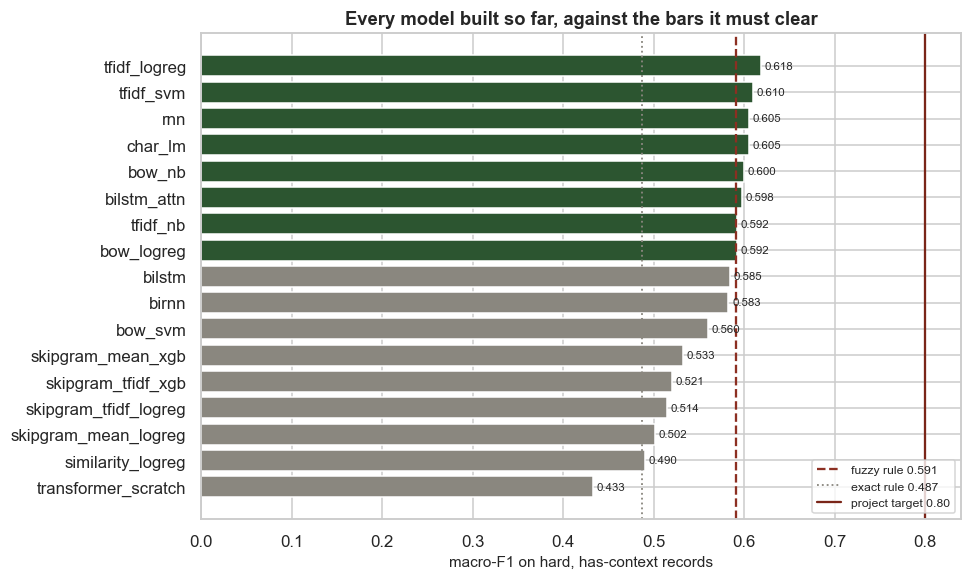

8 of 17 models beat the fuzzy rule on the hard subset.
None reaches the 0.80 target. Best so far: tfidf_logreg at 0.618.


In [23]:
everything = leaderboard(["M1", "M2", "M11", "M12", "M3", "M13", "M4", "M5"])
everything = everything.dropna(subset=["hard"]).sort_values("hard")

fig, ax = plt.subplots(figsize=(9, max(4, .32 * len(everything))))
colours = [CORRECT if h > FUZZY_BAR else NEUTRAL for h in everything["hard"]]
ax.barh(everything["short"], everything["hard"], color=colours)
ax.axvline(FUZZY_BAR, color=WRONG, lw=1.5, ls="--", label=f"fuzzy rule {FUZZY_BAR:.3f}")
ax.axvline(EXACT_BAR, color=NEUTRAL, lw=1.2, ls=":", label=f"exact rule {EXACT_BAR:.3f}")
ax.axvline(0.80, color=ACCENT, lw=1.5, label="project target 0.80")
ax.set_xlabel("macro-F1 on hard, has-context records")
ax.set_title("Every model built so far, against the bars it must clear")
ax.legend(fontsize=8, loc="lower right")
for i, (_, row) in enumerate(everything.iterrows()):
    ax.text(row["hard"] + .004, i, f"{row['hard']:.3f}", va="center", fontsize=7.5)
plt.show()

cleared = everything[everything["hard"] > FUZZY_BAR]
print(f"{len(cleared)} of {len(everything)} models beat the fuzzy rule on the hard subset.")
print(f"None reaches the 0.80 target. Best so far: {everything.iloc[-1]['short']} "
      f"at {everything.iloc[-1]['hard']:.3f}.")

### Is any difference real, or just noise?

Two models differing by 0.01 on 218 records is usually noise. McNemar's test looks only at the
records where they **disagree**: if each is right about as often as the other, the gap means
nothing. The confidence interval resamples **pairs**, not records, because the two answers to
one question rise and fall together.

In [24]:
from train_classical import fit_model

best_name = everything.iloc[-1]["short"]
hard_idx = [i for i, r in enumerate(dev) if r["context"] and r["difficulty"] == "hard"]
hard_truth = [dev[i]["label"] for i in hard_idx]

fuzzy_all = evaluate.baseline_predictions(dev, "fuzzy")
fuzzy_pred = [fuzzy_all[i] for i in hard_idx]

try:
    model = fit_model("tfidf_logreg", train, 42, "F2", "V1", None)
    preds = model.predict(dev)
    model_pred = [preds[i] for i in hard_idx]
    wins_model, wins_rule, p = evaluate.mcnemar(hard_truth, model_pred, fuzzy_pred)
    low, high = evaluate.bootstrap_interval([dev[i] for i in hard_idx], model_pred)

    print(f"tfidf_logreg vs the fuzzy rule, on {len(hard_idx)} hard records")
    print(f"  model      {evaluate.macro_f1(hard_truth, model_pred):.3f}   "
          f"95% interval {low:.3f} to {high:.3f}")
    print(f"  fuzzy rule {evaluate.macro_f1(hard_truth, fuzzy_pred):.3f}")
    print(f"  they disagree on {wins_model + wins_rule} records: "
          f"model right {wins_model}, rule right {wins_rule}")
    print(f"  McNemar p = {p:.3f}  ->",
          "TOO CLOSE TO CALL" if p > 0.05 else "a real difference")
except Exception as exc:
    print("skipped:", exc)

tfidf_logreg vs the fuzzy rule, on 218 hard records
  model      0.610   95% interval 0.554 to 0.665
  fuzzy rule 0.591
  they disagree on 98 records: model right 51, rule right 47
  McNemar p = 0.762  -> TOO CLOSE TO CALL


---
## What this project found

**1. The best-scoring model is the least useful one.**
The similarity-feature model tops the overall table and sits near the bottom on the hard
records. Its heaviest weight is "does the answer appear in the passage". It learned the
shortcut. Ranked by the overall column it would look like the best thing built here.

**2. The textbook preprocessing pipeline does not earn its place.**
Stop-word removal and stemming move the score by less than the noise between random seeds.
But deleting negation words costs about a quarter of the score on contradiction errors — and
the headline number never shows it.

**3. Every model so far lands between 0.49 and 0.62 on hard records.**
0.50 is a coin toss and the target is 0.80. This is the expected result at this data size, not
a failure: none of these models can line an answer up against a passage and check a fact.
Reaching the target is what the pretrained encoders and further pretraining are for.

**4. A two-line string-matching rule is a genuinely hard baseline.**
On hard records it scores 0.591, and most models on the ladder do not beat it. Any result
reported without that number beside it is not meaningful.

---

### Honest limitations

- **Dev was used to choose when to stop training**, so these dev scores are slightly
  optimistic. The `test` split has never been opened and is scored exactly once, at the end.
- **Per-error-type results exist for dev and test only** — the training set was type-labelled
  on a 20% sample (PRD §5.1c).
- **Attention shows what a model used, not that it reasoned.**

### What comes next

M6 further pretraining · M7 ensembling · M8 an LLM reference point, reported *beside* these
models rather than blended into them · M14 the word-order diagnostic · then the single,
final evaluation on `test`.